# Lecture 5: Single-Factor Security Markets, the Single-Index Model, Beta, Alpha, and Active Portfolio Choice

## Investment Analysis

This lecture introduces single-factor models of security returns.

The central idea is simple:

> Much of the comovement among individual securities comes from their shared exposure to a common market factor.

This lecture covers the single-index model, security characteristic lines, beta, alpha, residual risk, regression estimation, statistical significance, diversification under the index model, adjusted beta, forecasting beta, industry-index models, and the Treynor-Black model of active portfolio construction.

The lecture connects three objects:

1. **Economic risk exposure**: how sensitive is a security to common market shocks?
2. **Statistical estimation**: how do we estimate beta, alpha, residual volatility, standard errors, and $t$-statistics?
3. **Portfolio construction**: how can security analysis forecasts of alpha be combined with index investing?

# 1. Learning Objectives

By the end of this lecture, students should be able to:

1. Explain how a single common factor can generate covariance across many securities.
2. Define and estimate the single-index model.
3. Interpret beta, alpha, and residual risk.
4. Construct and interpret a security characteristic line.
5. Calculate covariance between two firms' returns in a single-factor model.
6. Distinguish systematic risk from idiosyncratic risk.
7. Explain how diversification changes portfolio risk in the index model.
8. Interpret regression output: standard errors, $t$-statistics, $R^2$, and statistical significance.
9. Explain the difference between raw-return regressions and excess-return regressions.
10. Explain why estimated alphas and betas are ex post statistics.
11. Compute and interpret adjusted beta.
12. Describe how beta may be forecast using past beta and firm characteristics.
13. Explain the Treynor-Black model.
14. Calculate active portfolio weights from alpha forecasts and residual variances.
15. Interpret the information ratio.

# 2. Setup: Python Libraries

We use simulated monthly returns so that the true data-generating process is known. This lets us compare estimated betas and alphas with the true model parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(2026)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Matplotlib is building the font cache; this may take a moment.


# 3. The Economic Motivation: Why Securities Move Together

Suppose the return on firm $i$ depends partly on an economy-wide shock and partly on firm-specific news.

A simple single-factor representation is:

$$
R_i = \alpha_i + \beta_i R_M + \epsilon_i
$$

where:

- $R_i$ is the return on stock $i$,
- $R_M$ is the market index return,
- $\alpha_i$ is the intercept,
- $\beta_i$ is the sensitivity of stock $i$ to the market,
- $\epsilon_i$ is the firm-specific residual.

The market factor captures common shocks such as recessions, interest-rate changes, inflation surprises, changes in aggregate risk appetite, and economy-wide earnings news.

The residual captures firm-specific shocks such as product launches, lawsuits, management changes, accounting news, and firm-specific earnings surprises.

# 4. Covariances Between Two Firms in a Single-Factor Model

Let two stocks have returns:

$$
R_i = \alpha_i + \beta_i R_M + \epsilon_i
$$

and:

$$
R_j = \alpha_j + \beta_j R_M + \epsilon_j
$$

Assume:

$$
\operatorname{Cov}(R_M,\epsilon_i)=0
$$

$$
\operatorname{Cov}(R_M,\epsilon_j)=0
$$

and:

$$
\operatorname{Cov}(\epsilon_i,\epsilon_j)=0
$$

Then:

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\operatorname{Var}(R_M)
$$

Thus, the covariance between two firms' returns depends on each firm's sensitivity to the common market shock and on the variance of the market shock.

In [2]:
market_var = 0.04
beta_i = 1.20
beta_j = 0.80
cov_ij = beta_i * beta_j * market_var
print(f"Market variance: {market_var:.4f}")
print(f"Beta of firm i: {beta_i:.2f}")
print(f"Beta of firm j: {beta_j:.2f}")
print(f"Model-implied covariance between firm i and firm j: {cov_ij:.4f}")

Market variance: 0.0400
Beta of firm i: 1.20
Beta of firm j: 0.80
Model-implied covariance between firm i and firm j: 0.0384


# 5. The Single-Index Model

The single-index model writes each stock's excess return as a linear function of the market excess return:

$$
R_i - R_f = \alpha_i + \beta_i(R_M - R_f) + \epsilon_i
$$

where:

- $R_f$ is the risk-free rate,
- $R_M - R_f$ is the market risk premium,
- $R_i - R_f$ is the stock's excess return.

The residual satisfies:

$$
\mathbb{E}[\epsilon_i]=0
$$

and:

$$
\operatorname{Cov}(R_M-R_f,\epsilon_i)=0
$$

The variance decomposition is:

$$
\sigma_i^2=\beta_i^2\sigma_M^2+\sigma_{\epsilon_i}^2
$$

where $\beta_i^2\sigma_M^2$ is systematic variance and $\sigma_{\epsilon_i}^2$ is idiosyncratic variance.

# 6. Simulating a Single-Index Security Market

We simulate monthly returns for a risk-free asset, a market index, and five individual stocks.

The true model is:

$$
R_i - R_f = \alpha_i + \beta_i(R_M-R_f)+\epsilon_i
$$

The residuals are independent across firms.

In [3]:
T = 180
rf_monthly = 0.002
mu_market_excess_monthly = 0.005
sigma_market_monthly = 0.045

market_excess = np.random.normal(mu_market_excess_monthly, sigma_market_monthly, T)
market_return = rf_monthly + market_excess

tickers = ["DefensiveCo", "MarketLikeCo", "CyclicalCo", "GrowthCo", "TurnaroundCo"]
true_alpha = np.array([0.0005, 0.0000, -0.0002, 0.0010, -0.0010])
true_beta = np.array([0.60, 1.00, 1.40, 1.25, 1.70])
true_resid_sigma = np.array([0.025, 0.030, 0.045, 0.060, 0.080])

stock_excess = {}
for name, a, b, s in zip(tickers, true_alpha, true_beta, true_resid_sigma):
    eps = np.random.normal(0, s, T)
    stock_excess[name] = a + b * market_excess + eps

data = pd.DataFrame(stock_excess)
data["Market Excess"] = market_excess
data["Market Return"] = market_return
data["Risk-Free Rate"] = rf_monthly
for name in tickers:
    data[name + " Return"] = data[name] + rf_monthly

data.index = pd.date_range("2011-01-31", periods=T, freq="ME")
data.head()

,DefensiveCo,MarketLikeCo,CyclicalCo,GrowthCo,TurnaroundCo,Market Excess,Market Return,Risk-Free Rate,DefensiveCo Return,MarketLikeCo Return,CyclicalCo Return,GrowthCo Return,TurnaroundCo Return
2011-01-31,0.0439,-0.0559,-0.0611,-0.0943,-0.0147,-0.0144,-0.0124,0.0020,0.0459,-0.0539,-0.0591,-0.0923,-0.0127
2011-02-28,-0.0860,-0.0811,-0.0930,-0.1208,-0.0159,-0.0577,-0.0557,0.0020,-0.0840,-0.0791,-0.0910,-0.1188,-0.0139
2011-03-31,0.0117,0.0017,0.0039,0.0177,0.0754,0.0190,0.0210,0.0020,0.0137,0.0037,0.0059,0.0197,0.0774
2011-04-30,-0.0048,0.0200,0.0150,-0.0112,0.0802,0.0044,0.0064,0.0020,-0.0028,0.0220,0.0170,-0.0092,0.0822
2011-05-31,0.0934,0.0866,0.0878,0.0716,0.0502,0.0702,0.0722,0.0020,0.0954,0.0886,0.0898,0.0736,0.0522


# 7. Scatter Plots and the Security Characteristic Line

The **security characteristic line**, or SCL, plots a stock's excess return against the market excess return.

The regression line is:

$$
R_i - R_f = \alpha_i + \beta_i(R_M-R_f) + \epsilon_i
$$

The slope is beta. The intercept is alpha. The vertical distance from an observation to the fitted line is the residual.

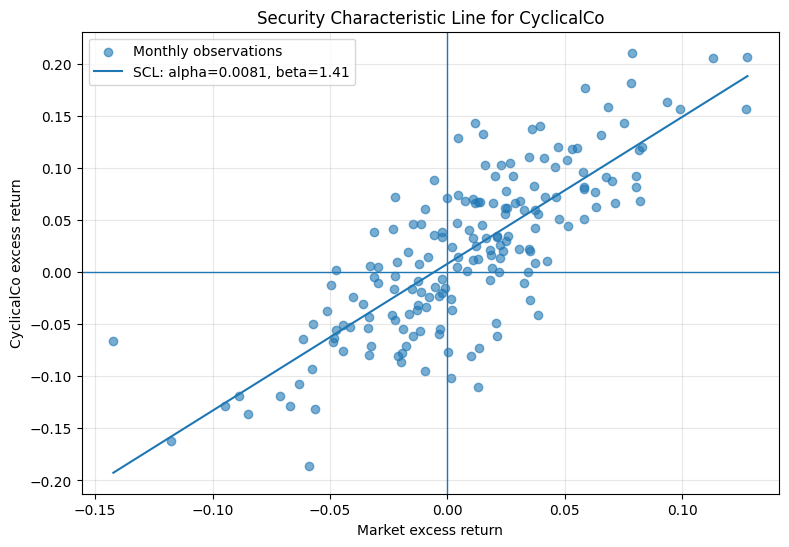

Estimated alpha: 0.8099% per month
Estimated beta: 1.4109
R-squared: 0.6269


In [4]:
stock = "CyclicalCo"
x = data["Market Excess"].values
y = data[stock].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.6, label="Monthly observations")
plt.plot(x_line, y_line, label=f"SCL: alpha={intercept:.4f}, beta={slope:.2f}")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Market excess return")
plt.ylabel(f"{stock} excess return")
plt.title(f"Security Characteristic Line for {stock}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated alpha: {intercept:.4%} per month")
print(f"Estimated beta: {slope:.4f}")
print(f"R-squared: {r_value**2:.4f}")

# 8. Regression, Alpha, Beta, and Residuals

Least squares chooses $\hat{\alpha}$ and $\hat{\beta}$ to minimize:

$$
\sum_{t=1}^T\left[(R_{i,t}-R_{f,t})-\alpha-\beta(R_{M,t}-R_{f,t})\right]^2
$$

The fitted value is:

$$
\widehat{R_{i,t}-R_{f,t}}=\hat{\alpha}_i+\hat{\beta}_i(R_{M,t}-R_{f,t})
$$

The residual is:

$$
\hat{\epsilon}_{i,t}=(R_{i,t}-R_{f,t})-\widehat{R_{i,t}-R_{f,t}}
$$

Beta measures systematic market exposure. Alpha measures average return unexplained by market exposure within the historical sample. Residual volatility measures firm-specific risk.

In [5]:
def ols_simple(y, x):
    y = np.asarray(y)
    x = np.asarray(x)
    X = np.column_stack([np.ones(len(x)), x])
    beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
    fitted = X @ beta_hat
    resid = y - fitted
    n, k = X.shape
    s2 = (resid @ resid) / (n - k)
    cov_beta = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov_beta))
    t_stats = beta_hat / se
    ss_tot = ((y - y.mean()) @ (y - y.mean()))
    ss_res = resid @ resid
    r2 = 1 - ss_res / ss_tot
    return {"alpha": beta_hat[0], "beta": beta_hat[1], "residuals": resid, "fitted": fitted,
            "se_alpha": se[0], "se_beta": se[1], "t_alpha": t_stats[0], "t_beta": t_stats[1],
            "resid_sigma": np.sqrt(s2), "r2": r2}

reg_results = {}
rows = []
for stock in tickers:
    res = ols_simple(data[stock], data["Market Excess"])
    reg_results[stock] = res
    idx = tickers.index(stock)
    rows.append({"Stock": stock, "True Alpha": true_alpha[idx], "Estimated Alpha": res["alpha"],
                 "SE Alpha": res["se_alpha"], "t Alpha": res["t_alpha"],
                 "True Beta": true_beta[idx], "Estimated Beta": res["beta"],
                 "SE Beta": res["se_beta"], "t Beta": res["t_beta"],
                 "Residual Std Dev": res["resid_sigma"], "R-squared": res["r2"]})
reg_table = pd.DataFrame(rows)
reg_table

,Stock,True Alpha,Estimated Alpha,SE Alpha,t Alpha,True Beta,Estimated Beta,SE Beta,t Beta,Residual Std Dev,R-squared
0,DefensiveCo,0.0005,0.0018,0.0020,0.9134,0.6000,0.5425,0.0451,12.0237,0.0263,0.4482
1,MarketLikeCo,0.0000,0.0012,0.0023,0.5046,1.0000,0.9114,0.0514,17.7320,0.0300,0.6385
2,CyclicalCo,-0.0002,0.0081,0.0036,2.2361,1.4000,1.4109,0.0816,17.2950,0.0476,0.6269
3,GrowthCo,0.0010,0.0104,0.0046,2.2494,1.2500,1.1875,0.1038,11.4407,0.0606,0.4237
4,TurnaroundCo,-0.0010,-0.0082,0.0072,-1.1461,1.7000,1.7299,0.1614,10.7204,0.0942,0.3923


# 9. Standard Errors, $t$-Statistics, and Statistical Significance

A coefficient estimate is uncertain. The standard error measures sampling uncertainty around the estimate.

For alpha:

$$
t_{\alpha}=\frac{\hat{\alpha}}{SE(\hat{\alpha})}
$$

For beta:

$$
t_{\beta}=\frac{\hat{\beta}}{SE(\hat{\beta})}
$$

A large absolute $t$-statistic means the estimate is large relative to its standard error. A common rule of thumb is that $|t|>2$ indicates statistical significance at about the 5% level in many large-sample settings.

In [6]:
reg_table["Alpha Significant by |t|>2"] = reg_table["t Alpha"].abs() > 2
reg_table["Beta Significant by |t|>2"] = reg_table["t Beta"].abs() > 2
reg_table[["Stock", "Estimated Alpha", "t Alpha", "Alpha Significant by |t|>2",
           "Estimated Beta", "t Beta", "Beta Significant by |t|>2", "R-squared"]]

,Stock,Estimated Alpha,t Alpha,Alpha Significant by |t|>2,Estimated Beta,t Beta,Beta Significant by |t|>2,R-squared
0,DefensiveCo,0.0018,0.9134,False,0.5425,12.0237,True,0.4482
1,MarketLikeCo,0.0012,0.5046,False,0.9114,17.7320,True,0.6385
2,CyclicalCo,0.0081,2.2361,True,1.4109,17.2950,True,0.6269
3,GrowthCo,0.0104,2.2494,True,1.1875,11.4407,True,0.4237
4,TurnaroundCo,-0.0082,-1.1461,False,1.7299,10.7204,True,0.3923


# 10. Explanatory Power of the Security Characteristic Line

The $R^2$ of the regression measures the fraction of the stock's return variance explained by the market factor.

A high $R^2$ means the market factor explains much of the stock's return variation. A low $R^2$ means firm-specific residual variation is large relative to market-related variation.

In [7]:
market_variance_sample = data["Market Excess"].var(ddof=1)
variance_rows = []
for stock in tickers:
    beta_hat = reg_results[stock]["beta"]
    resid_var = reg_results[stock]["resid_sigma"]**2
    total_var = data[stock].var(ddof=1)
    systematic_var = beta_hat**2 * market_variance_sample
    variance_rows.append({"Stock": stock, "Total Variance": total_var, "Systematic Variance": systematic_var,
                          "Residual Variance": resid_var, "Systematic Share": systematic_var / total_var,
                          "Residual Share": resid_var / total_var, "Regression R-squared": reg_results[stock]["r2"]})
variance_table = pd.DataFrame(variance_rows)
variance_table

,Stock,Total Variance,Systematic Variance,Residual Variance,Systematic Share,Residual Share,Regression R-squared
0,DefensiveCo,0.0012,0.0006,0.0007,0.4482,0.5549,0.4482
1,MarketLikeCo,0.0025,0.0016,0.0009,0.6385,0.3635,0.6385
2,CyclicalCo,0.0060,0.0038,0.0023,0.6269,0.3752,0.6269
3,GrowthCo,0.0063,0.0027,0.0037,0.4237,0.5795,0.4237
4,TurnaroundCo,0.0145,0.0057,0.0089,0.3923,0.6111,0.3923


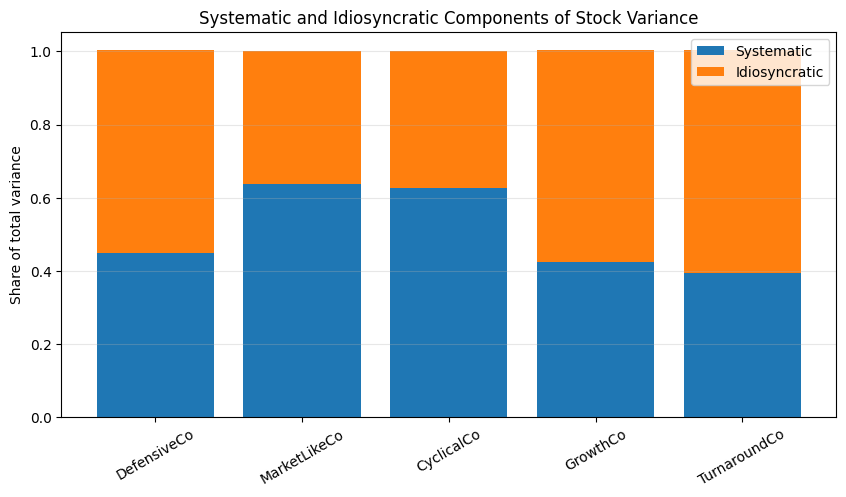

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(variance_table["Stock"], variance_table["Systematic Share"], label="Systematic")
plt.bar(variance_table["Stock"], variance_table["Residual Share"], bottom=variance_table["Systematic Share"], label="Idiosyncratic")
plt.ylabel("Share of total variance")
plt.title("Systematic and Idiosyncratic Components of Stock Variance")
plt.legend()
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 11. The Index Model and Diversification

For a portfolio of $N$ securities:

$$
R_p - R_f=\alpha_p+\beta_p(R_M-R_f)+\epsilon_p
$$

where:

$$
\alpha_p=\sum_{i=1}^N w_i\alpha_i
$$

$$
\beta_p=\sum_{i=1}^N w_i\beta_i
$$

and:

$$
\epsilon_p=\sum_{i=1}^N w_i\epsilon_i
$$

Portfolio variance is:

$$
\sigma_p^2=\beta_p^2\sigma_M^2+\sigma^2(\epsilon_p)
$$

If residuals are uncorrelated across firms:

$$
\sigma^2(\epsilon_p)=\sum_{i=1}^N w_i^2\sigma_{\epsilon_i}^2
$$

Diversification reduces residual risk, but the systematic-risk term remains.

In [9]:
N_values = np.arange(1, 101)
sigma_m = 0.18
avg_beta = 1.0
avg_resid_sigma = 0.35
systematic_std = np.full_like(N_values, avg_beta * sigma_m, dtype=float)
residual_var = avg_resid_sigma**2 / N_values
total_std = np.sqrt((avg_beta**2)*(sigma_m**2) + residual_var)

div_table = pd.DataFrame({"Number of Stocks": N_values, "Systematic Std Dev Floor": systematic_std,
                          "Total Portfolio Std Dev": total_std, "Residual Std Dev Component": np.sqrt(residual_var)})
div_table.iloc[[0, 4, 9, 19, 49, 99]]

,Number of Stocks,Systematic Std Dev Floor,Total Portfolio Std Dev,Residual Std Dev Component
0,1,0.1800,0.3936,0.3500
4,5,0.1800,0.2385,0.1565
9,10,0.1800,0.2113,0.1107
19,20,0.1800,0.1963,0.0783
49,50,0.1800,0.1867,0.0495
99,100,0.1800,0.1834,0.0350


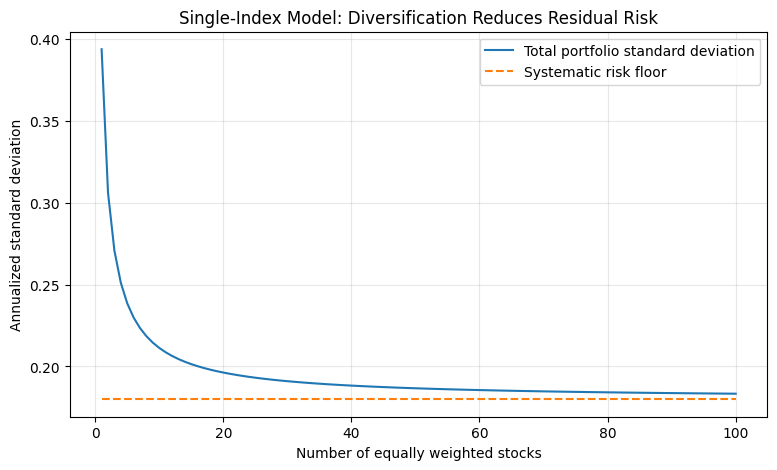

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(N_values, total_std, label="Total portfolio standard deviation")
plt.plot(N_values, systematic_std, linestyle="--", label="Systematic risk floor")
plt.xlabel("Number of equally weighted stocks")
plt.ylabel("Annualized standard deviation")
plt.title("Single-Index Model: Diversification Reduces Residual Risk")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 12. Raw-Return Regression Versus Excess-Return Regression

There are two common regressions.

## Raw-return market model

$$
R_i = a_i + b_iR_M + e_i
$$

## Excess-return single-index model

$$
R_i - R_f = \alpha_i + \beta_i(R_M-R_f)+\epsilon_i
$$

If the risk-free rate is constant, the slope estimates are the same:

$$
b_i=\beta_i
$$

but the intercepts differ.

When $R_f$ is constant:

$$
\alpha_i=a_i+(b_i-1)R_f
$$

The excess-return alpha is usually the more relevant performance evaluation object.

In [11]:
comparison_rows = []
for stock in tickers:
    raw_res = ols_simple(data[stock + " Return"], data["Market Return"])
    excess_res = ols_simple(data[stock], data["Market Excess"])
    implied_excess_alpha_from_raw = raw_res["alpha"] + (raw_res["beta"] - 1) * rf_monthly
    comparison_rows.append({"Stock": stock, "Raw Intercept a": raw_res["alpha"], "Raw Slope b": raw_res["beta"],
                            "Excess Alpha": excess_res["alpha"], "Excess Beta": excess_res["beta"],
                            "Implied Excess Alpha from Raw Model": implied_excess_alpha_from_raw})
comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,Stock,Raw Intercept a,Raw Slope b,Excess Alpha,Excess Beta,Implied Excess Alpha from Raw Model
0,DefensiveCo,0.0027,0.5425,0.0018,0.5425,0.0018
1,MarketLikeCo,0.0013,0.9114,0.0012,0.9114,0.0012
2,CyclicalCo,0.0073,1.4109,0.0081,1.4109,0.0081
3,GrowthCo,0.0100,1.1875,0.0104,1.1875,0.0104
4,TurnaroundCo,-0.0097,1.7299,-0.0082,1.7299,-0.0082


# 13. Ex Post Nature of Estimated Alphas and Betas

Estimated alphas and betas are historical statistics. They describe how a stock behaved in the sample used for estimation.

They are **ex post** estimates. They are not guaranteed forecasts.

Estimated betas and alphas may change because of changes in leverage, business mix, operating leverage, acquisitions, regulation, competition, interest-rate sensitivity, cyclicality, and estimation error.

# 14. Adjusted Beta

A common practical adjustment moves estimated beta toward one:

$$
\beta_{adj}=\frac{2}{3}\hat{\beta}+\frac{1}{3}(1)
$$

This is a simple shrinkage estimator. It reflects the idea that unusually high or low historical beta estimates may partly reflect noise and may tend to move toward the market average.

In [12]:
reg_table["Adjusted Beta"] = (2/3) * reg_table["Estimated Beta"] + (1/3) * 1.0
reg_table[["Stock", "Estimated Beta", "Adjusted Beta", "True Beta"]]

,Stock,Estimated Beta,Adjusted Beta,True Beta
0,DefensiveCo,0.5425,0.6950,0.6000
1,MarketLikeCo,0.9114,0.9410,1.0000
2,CyclicalCo,1.4109,1.2740,1.4000
3,GrowthCo,1.1875,1.1250,1.2500
4,TurnaroundCo,1.7299,1.4866,1.7000


# 15. Forecasting Beta with Past Beta and Firm Characteristics

A general beta forecast may use past beta and financial variables:

$$
\beta_{i,t+1}^{forecast}=c_0+c_1\hat{\beta}_{i,t}+c_2\text{Leverage}_{i,t}+c_3\text{Operating Leverage}_{i,t}+c_4\text{Size}_{i,t}+c_5\text{Industry Beta}_{i,t}
$$

Potential beta predictors include historical beta, financial leverage, operating leverage, revenue cyclicality, industry membership, size, liquidity, interest-rate sensitivity, and commodity exposure.

In [13]:
beta_forecast_demo = pd.DataFrame({
    "Stock": tickers,
    "Estimated Beta": reg_table["Estimated Beta"].values,
    "Adjusted Beta": reg_table["Adjusted Beta"].values,
    "Debt_to_Equity": [0.30, 0.60, 1.20, 0.45, 2.00],
    "Revenue_Cyclicality_Score": [0.20, 0.50, 0.90, 0.70, 1.00],
    "Industry_Beta": [0.70, 1.00, 1.30, 1.20, 1.50]
})

beta_forecast_demo["Fundamental Beta Forecast"] = (
    0.20 + 0.45 * beta_forecast_demo["Adjusted Beta"]
    + 0.10 * beta_forecast_demo["Debt_to_Equity"]
    + 0.25 * beta_forecast_demo["Revenue_Cyclicality_Score"]
    + 0.20 * beta_forecast_demo["Industry_Beta"]
)
beta_forecast_demo

,Stock,Estimated Beta,Adjusted Beta,Debt_to_Equity,Revenue_Cyclicality_Score,Industry_Beta,Fundamental Beta Forecast
0,DefensiveCo,0.5425,0.6950,0.3000,0.2000,0.7000,0.7327
1,MarketLikeCo,0.9114,0.9410,0.6000,0.5000,1.0000,1.0084
2,CyclicalCo,1.4109,1.2740,1.2000,0.9000,1.3000,1.3783
3,GrowthCo,1.1875,1.1250,0.4500,0.7000,1.2000,1.1662
4,TurnaroundCo,1.7299,1.4866,2.0000,1.0000,1.5000,1.6190


# 16. Industry Version of the Index Model

Sometimes a stock is better explained by both the market and its industry:

$$
R_i - R_f=\alpha_i+\beta_{iM}(R_M-R_f)+\beta_{iI}(R_I-R_f)+\epsilon_i
$$

where $R_I$ is an industry index return.

Industry models are useful when firms share shocks not fully captured by the market index: oil prices for energy firms, interest rates for banks, semiconductor cycles for chip firms, or commodity prices for materials firms.

In [14]:
industry_shock = np.random.normal(0.001, 0.035, T)
industry_excess = 0.70 * market_excess + industry_shock
dual_factor_stock = 0.0005 + 0.85 * market_excess + 0.65 * industry_shock + np.random.normal(0, 0.030, T)
industry_df = pd.DataFrame({"Stock Excess": dual_factor_stock, "Market Excess": market_excess,
                            "Industry Excess": industry_excess, "Industry Shock": industry_shock}, index=data.index)
industry_df.head()

,Stock Excess,Market Excess,Industry Excess,Industry Shock
2011-01-31,-0.1109,-0.0144,-0.0700,-0.0599
2011-02-28,-0.0397,-0.0577,-0.0704,-0.0301
2011-03-31,-0.0085,0.0190,0.0034,-0.0099
2011-04-30,-0.0221,0.0044,-0.0158,-0.0189
2011-05-31,0.1097,0.0702,0.1658,0.1166


In [15]:
def ols_multiple(y, X, column_names):
    y = np.asarray(y)
    X = np.asarray(X)
    X_design = np.column_stack([np.ones(len(y)), X])
    beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    fitted = X_design @ beta_hat
    resid = y - fitted
    n, k = X_design.shape
    s2 = resid @ resid / (n-k)
    cov_beta = s2 * np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(cov_beta))
    t = beta_hat / se
    ss_tot = ((y-y.mean()) @ (y-y.mean()))
    ss_res = resid @ resid
    r2 = 1 - ss_res/ss_tot
    return pd.DataFrame({"Coefficient": beta_hat, "Std Error": se, "t-stat": t}, index=["Intercept"] + column_names), r2

market_only_table, market_only_r2 = ols_multiple(industry_df["Stock Excess"], industry_df[["Market Excess"]], ["Market Excess"])
industry_model_table, industry_model_r2 = ols_multiple(industry_df["Stock Excess"], industry_df[["Market Excess", "Industry Shock"]], ["Market Excess", "Industry Shock"])

print("Market-only regression")
display(market_only_table)
print(f"R-squared: {market_only_r2:.4f}")
print("\nMarket plus industry shock regression")
display(industry_model_table)
print(f"R-squared: {industry_model_r2:.4f}")

Market-only regression


,Coefficient,Std Error,t-stat
Intercept,0.0023,0.0030,0.7446
Market Excess,0.7526,0.0683,11.0223


R-squared: 0.4057

Market plus industry shock regression


,Coefficient,Std Error,t-stat
Intercept,0.0013,0.0024,0.5516
Market Excess,0.7789,0.0549,14.1932
Industry Shock,0.6675,0.0670,9.9610


R-squared: 0.6192


# 17. The Single-Index Model and Portfolio Covariance Simplification

Without a factor model, the covariance matrix for $N$ assets requires:

$$
\frac{N(N-1)}{2}
$$

pairwise covariance estimates plus $N$ variances.

The single-index model reduces this. Estimate $\alpha_i$, $\beta_i$, $\sigma_{\epsilon_i}^2$, and $\sigma_M^2$. Then:

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\sigma_M^2
$$

for $i\neq j$, and:

$$
\operatorname{Var}(R_i)=\beta_i^2\sigma_M^2+\sigma_{\epsilon_i}^2
$$

for $i=j$.

In [16]:
estimated_betas = reg_table["Estimated Beta"].values
estimated_resid_vars = reg_table["Residual Std Dev"].values**2
market_var = data["Market Excess"].var(ddof=1)

single_index_cov = np.outer(estimated_betas, estimated_betas) * market_var
np.fill_diagonal(single_index_cov, estimated_betas**2 * market_var + estimated_resid_vars)

sample_cov = data[tickers].cov().values
single_index_cov_df = pd.DataFrame(single_index_cov, index=tickers, columns=tickers)
sample_cov_df = pd.DataFrame(sample_cov, index=tickers, columns=tickers)

print("Single-index model covariance matrix")
display(single_index_cov_df)
print("Sample covariance matrix")
display(sample_cov_df)

Single-index model covariance matrix


,DefensiveCo,MarketLikeCo,CyclicalCo,GrowthCo,TurnaroundCo
DefensiveCo,0.0013,0.0009,0.0015,0.0012,0.0018
MarketLikeCo,0.0009,0.0025,0.0024,0.0021,0.0030
CyclicalCo,0.0015,0.0024,0.0061,0.0032,0.0046
GrowthCo,0.0012,0.0021,0.0032,0.0064,0.0039
TurnaroundCo,0.0018,0.0030,0.0046,0.0039,0.0146


Sample covariance matrix


,DefensiveCo,MarketLikeCo,CyclicalCo,GrowthCo,TurnaroundCo
DefensiveCo,0.0012,0.0009,0.0014,0.0011,0.0018
MarketLikeCo,0.0009,0.0025,0.0024,0.0022,0.0029
CyclicalCo,0.0014,0.0024,0.0060,0.0032,0.0051
GrowthCo,0.0011,0.0022,0.0032,0.0063,0.0038
TurnaroundCo,0.0018,0.0029,0.0051,0.0038,0.0145


# 18. Optimal Risky Portfolio in the Single-Index Model

The Markowitz optimal risky portfolio can be computed using:

$$
\mathbf{w}_T=\frac{\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_e}{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_e}
$$

In the single-index model:

$$
\boldsymbol{\Sigma}=\sigma_M^2\boldsymbol{\beta}\boldsymbol{\beta}'+\mathbf{D}
$$

where $\boldsymbol{\beta}$ is the vector of betas and $\mathbf{D}$ is a diagonal matrix of residual variances.

In [17]:
mu_excess_est = data[tickers].mean().values
ones = np.ones(len(tickers))
inv_cov = np.linalg.inv(single_index_cov)
w_tangency_index = inv_cov @ mu_excess_est
w_tangency_index = w_tangency_index / (ones @ inv_cov @ mu_excess_est)

portfolio_mu_excess = w_tangency_index @ mu_excess_est
portfolio_sigma = np.sqrt(w_tangency_index @ single_index_cov @ w_tangency_index)
portfolio_sharpe = portfolio_mu_excess / portfolio_sigma

pd.DataFrame({"Stock": tickers, "Single-Index Tangency Weight": w_tangency_index})

,Stock,Single-Index Tangency Weight
0,DefensiveCo,0.2919
1,MarketLikeCo,-0.0200
2,CyclicalCo,0.5067
3,GrowthCo,0.4436
4,TurnaroundCo,-0.2222


In [18]:
print(f"Monthly expected excess return: {portfolio_mu_excess:.4%}")
print(f"Monthly standard deviation: {portfolio_sigma:.4%}")
print(f"Monthly Sharpe ratio: {portfolio_sharpe:.4f}")
print(f"Sum of weights: {w_tangency_index.sum():.4f}")

Monthly expected excess return: 1.9833%
Monthly standard deviation: 6.0796%
Monthly Sharpe ratio: 0.3262
Sum of weights: 1.0000


Historical average returns are noisy estimates of expected returns. This is why Treynor-Black separates the passive benchmark from active alpha forecasts.

# 19. Security Analysis and Forecasting Alphas

In the Treynor-Black framework, security analysis is valuable because it may produce forecasts of alpha.

For stock $i$:

$$
\alpha_i > 0
$$

means the analyst expects the stock to outperform after adjusting for market exposure.

$$
\alpha_i < 0
$$

means the analyst expects the stock to underperform after adjusting for market exposure.

The analyst's forecast must be compared with residual risk. A large alpha with enormous residual volatility may be less attractive than a smaller but more reliable alpha.

# 20. The Information Ratio

For an active position or active portfolio, the information ratio is:

$$
IR=\frac{\alpha}{\sigma_{\epsilon}}
$$

For Treynor-Black active weighting, a natural score is:

$$
\frac{\alpha_i}{\sigma_{\epsilon_i}^2}
$$

because optimal active weights are larger when alpha is high and residual variance is low.

In [19]:
alpha_forecasts = pd.Series([0.0015, 0.0005, -0.0010, 0.0020, -0.0005], index=tickers, name="Forecast Alpha")
resid_sigma_est = pd.Series(reg_table["Residual Std Dev"].values, index=tickers)
resid_var_est = resid_sigma_est**2

alpha_analysis = pd.DataFrame({
    "Forecast Alpha": alpha_forecasts,
    "Residual Std Dev": resid_sigma_est,
    "Residual Variance": resid_var_est,
    "Information Ratio alpha/sigma_e": alpha_forecasts / resid_sigma_est,
    "Treynor-Black Score alpha/sigma_e^2": alpha_forecasts / resid_var_est
})
alpha_analysis

,Forecast Alpha,Residual Std Dev,Residual Variance,Information Ratio alpha/sigma_e,Treynor-Black Score alpha/sigma_e^2
DefensiveCo,0.0015,0.0263,0.0007,0.0570,2.1625
MarketLikeCo,0.0005,0.0300,0.0009,0.0167,0.5554
CyclicalCo,-0.0010,0.0476,0.0023,-0.0210,-0.4409
GrowthCo,0.0020,0.0606,0.0037,0.0330,0.5448
TurnaroundCo,-0.0005,0.0942,0.0089,-0.0053,-0.0564


# 21. Treynor-Black Active Portfolio Weights

The Treynor-Black model combines a passive market index portfolio with an active portfolio based on analyst alpha forecasts.

A simplified active weight score is:

$$
w_i^A \propto \frac{\alpha_i}{\sigma_{\epsilon_i}^2}
$$

Then normalize active weights depending on the active-risk budget.

Positive weights indicate overweight or long active positions. Negative weights indicate underweight or short active positions.

In [20]:
tb_scores = alpha_forecasts / resid_var_est
active_weights = tb_scores / tb_scores.abs().sum()
active_alpha = (active_weights * alpha_forecasts).sum()
active_resid_var = ((active_weights**2) * resid_var_est).sum()
active_resid_sigma = np.sqrt(active_resid_var)
active_ir = active_alpha / active_resid_sigma

tb_table = pd.DataFrame({
    "Forecast Alpha": alpha_forecasts,
    "Residual Variance": resid_var_est,
    "TB Score alpha/sigma_e^2": tb_scores,
    "Active Weight": active_weights
})

display(tb_table)
print(f"Active portfolio alpha: {active_alpha:.4%} per month")
print(f"Active portfolio residual std dev: {active_resid_sigma:.4%} per month")
print(f"Active portfolio information ratio: {active_ir:.4f} per month")

,Forecast Alpha,Residual Variance,TB Score alpha/sigma_e^2,Active Weight
DefensiveCo,0.0015,0.0007,2.1625,0.5751
MarketLikeCo,0.0005,0.0009,0.5554,0.1477
CyclicalCo,-0.0010,0.0023,-0.4409,-0.1173
GrowthCo,0.0020,0.0037,0.5448,0.1449
TurnaroundCo,-0.0005,0.0089,-0.0564,-0.0150


Active portfolio alpha: 0.1351% per month
Active portfolio residual std dev: 1.8956% per month
Active portfolio information ratio: 0.0713 per month


# 22. Combining the Active Portfolio with the Passive Market

The Treynor-Black investor combines the passive market portfolio and the active portfolio.

The active portfolio is valuable if it has a positive information ratio. The exact allocation depends on alpha, residual risk, benchmark risk, and active-risk tolerance.

In [21]:
market_mean_excess = data["Market Excess"].mean()
market_std = data["Market Excess"].std(ddof=1)
market_sharpe = market_mean_excess / market_std
active_beta = (active_weights.values * estimated_betas).sum()
active_total_mean_excess = active_alpha + active_beta * market_mean_excess
active_total_var = active_beta**2 * market_std**2 + active_resid_var
active_total_std = np.sqrt(active_total_var)

active_summary = pd.DataFrame({
    "Object": ["Market index", "Active portfolio"],
    "Expected Excess Return": [market_mean_excess, active_total_mean_excess],
    "Std Dev": [market_std, active_total_std],
    "Sharpe Ratio": [market_sharpe, active_total_mean_excess / active_total_std],
    "Alpha": [0.0, active_alpha],
    "Beta": [1.0, active_beta],
    "Residual Std Dev": [0.0, active_resid_sigma]
})
active_summary

,Object,Expected Excess Return,Std Dev,Sharpe Ratio,Alpha,Beta,Residual Std Dev
0,Market index,0.0088,0.0436,0.2021,0.0000,1.0000,0.0000
1,Active portfolio,0.0051,0.0266,0.1925,0.0014,0.4273,0.0190


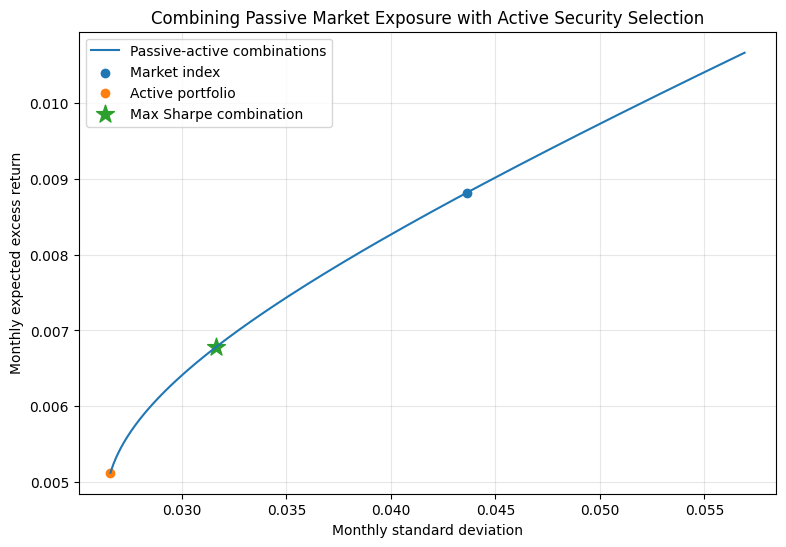

Best active weight in grid: 0.55
Best combined monthly Sharpe ratio: 0.2143


In [22]:
wA_grid = np.linspace(-0.5, 1.0, 151)
cov_market_active = active_beta * market_std**2
combined_mean = (1-wA_grid)*market_mean_excess + wA_grid*active_total_mean_excess
combined_var = ((1-wA_grid)**2 * market_std**2 + wA_grid**2 * active_total_var + 2*(1-wA_grid)*wA_grid*cov_market_active)
combined_std = np.sqrt(combined_var)
combined_sharpe = combined_mean / combined_std
best_idx = np.argmax(combined_sharpe)

plt.figure(figsize=(9, 6))
plt.plot(combined_std, combined_mean, label="Passive-active combinations")
plt.scatter([market_std], [market_mean_excess], label="Market index")
plt.scatter([active_total_std], [active_total_mean_excess], label="Active portfolio")
plt.scatter([combined_std[best_idx]], [combined_mean[best_idx]], marker="*", s=180, label="Max Sharpe combination")
plt.xlabel("Monthly standard deviation")
plt.ylabel("Monthly expected excess return")
plt.title("Combining Passive Market Exposure with Active Security Selection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best active weight in grid: {wA_grid[best_idx]:.2f}")
print(f"Best combined monthly Sharpe ratio: {combined_sharpe[best_idx]:.4f}")

# 23. Alpha, Beta, and Active Management

The Treynor-Black framework imposes discipline on active management.

It asks:

1. What is the security's alpha?
2. How uncertain is that alpha?
3. How much residual risk does the security have?
4. Does the security add something not already captured by market exposure?
5. How should the active view be scaled?

A high expected return is not enough. If the high expected return merely compensates for high beta, it is not alpha.

# 24. Ex Ante Versus Ex Post Alpha

Regression alpha is estimated from historical data. This is ex post alpha.

Investment decisions require ex ante alpha.

A stock may have positive historical alpha because of luck. Another stock may have negative historical alpha but positive expected alpha because the market has overreacted to bad news.

Security analysis tries to forecast ex ante alpha using information such as valuation, earnings quality, industry conditions, balance-sheet strength, management quality, catalysts, competitive advantage, accounting signals, and macro sensitivity.

The Treynor-Black model does not create alpha. It tells the analyst how to use alpha forecasts in a risk-controlled portfolio.

# 25. Summary of Key Formulas

## Single-index model

$$
R_i-R_f = \alpha_i+\beta_i(R_M-R_f)+\epsilon_i
$$

## Raw-return market model

$$
R_i = a_i+b_iR_M+e_i
$$

## Covariance between two firms in the single-factor model

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\sigma_M^2
$$

## Variance decomposition

$$
\sigma_i^2=\beta_i^2\sigma_M^2+\sigma_{\epsilon_i}^2
$$

## Portfolio beta

$$
\beta_p=\sum_i w_i\beta_i
$$

## Portfolio alpha

$$
\alpha_p=\sum_i w_i\alpha_i
$$

## Portfolio residual variance under independent residuals

$$
\sigma^2(\epsilon_p)=\sum_i w_i^2\sigma_{\epsilon_i}^2
$$

## $t$-statistic

$$
t_{\hat{\theta}}=\frac{\hat{\theta}}{SE(\hat{\theta})}
$$

## Adjusted beta

$$
\beta_{adj}=\frac{2}{3}\hat{\beta}+\frac{1}{3}
$$

## Single-index covariance matrix

$$
\boldsymbol{\Sigma}=\sigma_M^2\boldsymbol{\beta}\boldsymbol{\beta}'+\mathbf{D}
$$

## Treynor-Black active score

$$
w_i^A \propto \frac{\alpha_i}{\sigma_{\epsilon_i}^2}
$$

## Information ratio

$$
IR=\frac{\alpha}{\sigma_{\epsilon}}
$$

# 26. Final Takeaways

1. The single-index model explains comovement using a common market factor.
2. A stock's beta measures its sensitivity to market excess returns.
3. Alpha measures average performance unexplained by market exposure.
4. Residuals measure firm-specific return shocks.
5. The security characteristic line visualizes alpha, beta, and residual variation.
6. $R^2$ measures how much of a stock's variation is explained by the market factor.
7. Covariance between two stocks in the single-factor model depends on both betas and market variance.
8. Diversification reduces residual risk but not systematic market risk.
9. Raw-return and excess-return regressions have different intercept interpretations.
10. Estimated alpha and beta are ex post estimates, not guaranteed forecasts.
11. Adjusted beta shrinks historical beta toward one.
12. Beta forecasts can combine historical beta with forward-looking firm characteristics.
13. Industry-index models capture common sector shocks beyond broad market exposure.
14. Treynor-Black converts alpha forecasts into active weights using residual risk.
15. The information ratio measures active return per unit of active risk.
16. Security analysis matters when it produces reliable alpha forecasts that are large relative to residual volatility.